# Maxwell's attempt to unify electricity and magnetism inadvertently exposed a foundational flaw in classical mechanics: guaranteeing local charge conservation required a fixed wave speed $c$, forcing physics to choose between an absolute mechanical ether or a radical revision of spacetime.

* **Reed College: From Electrodynamics to Special Relativity**
* **URL:** `[https://www.reed.edu/physics/faculty/wheeler/documents/Electrodynamics/Class%20Notes/Chapter%202.pdf](https://www.reed.edu/physics/faculty/wheeler/documents/Electrodynamics/Class%20Notes/Chapter%202.pdf)`
* **Physical Motivation:** Details "Maxwell's Trick"—adding the displacement current term ($\mu_0 \epsilon_0 \frac{\partial \vec{E}}{\partial t}$) to Ampère's Law purely to enforce local charge conservation ($\nabla \cdot \vec{J} + \frac{\partial \rho}{\partial t} = 0$).
* **Intuitive Leap:** This correction mathematically compelled vacuum electrodynamics to predict waves moving at $c = 1/\sqrt{\mu_0 \epsilon_0}$, baking a fixed velocity directly into fundamental force laws regardless of observer motion.


* **Caltech Feynman Lectures: Magnetism and Relativity (Vol. II, Ch. 13)**
* **URL:** `[https://www.feynmanlectures.caltech.edu/II_13.html](https://www.feynmanlectures.caltech.edu/II_13.html)`
* **Physical Motivation:** Addresses the physical asymmetry that bothered Einstein: a moving magnet inducing current in a stationary wire versus a moving wire passing a stationary magnet.
* **Intuitive Leap:** Explains that magnetism is an inescapable relativistic side-effect of electrostatics. What appears as a magnetic force in one frame is identical to an electrostatic Coulomb force in another frame due to relativistic length contraction.


* **UNSW Einstein Light: Maxwell's Equations and Light Speed**
* **URL:** `[https://www.phys.unsw.edu.au/einsteinlight/jw/module3_Maxwell.htm](https://www.phys.unsw.edu.au/einsteinlight/jw/module3_Maxwell.htm)`
* **Physical Motivation:** Explores Einstein's famous thought experiment about chasing a light beam at speed $c$.
* **Intuitive Leap:** If an observer could catch up to a light wave, they would observe a spatially oscillating, stationary electromagnetic field. Because Faraday's and Ampère's laws require time-varying fields ($\frac{\partial \vec{B}}{\partial t} \leftrightarrow \frac{\partial \vec{E}}{\partial t}$) to generate each other, a frozen wave is physically impossible under Maxwell's laws, proving $c$ must be invariant.


* **Princeton University (Prof. Kirk T. McDonald): Maxwell and Special Relativity**
* **URL:** `[http://kirkmcd.princeton.edu/examples/maxwell_rel.pdf](http://kirkmcd.princeton.edu/examples/maxwell_rel.pdf)`
* **Physical Motivation:** Traces the historical collapse of mechanical "ether" models when applied to moving charges and moving circuits.
* **Intuitive Leap:** Illustrates how 19th-century physicists realized that static vacuum constants ($\epsilon_0, \mu_0$) are universal frame-independent properties of spacetime rather than elastic properties of a mechanical medium.


* **University of Illinois Physics Van: Constant Speed of Light Basis**
* **URL:** `[https://van.physics.illinois.edu/ask/listing/15181](https://van.physics.illinois.edu/ask/listing/15181)`
* **Physical Motivation:** Connects static laboratory measurements of charge attraction ($\epsilon_0$) and current repulsion ($\mu_0$) directly to dynamic wave propagation.
* **Intuitive Leap:** Demonstrates that if the speed of light changed between inertial reference frames, static electrostatic and magnetic forces would also have to change relative velocity, causing static laboratory apparatuses to behave inconsistently.

# Special Relativity as a Necessary Consequence of Maxwell's Equations

## Objective & Pedagogical Target
This notebook is designed for undergraduate physics students. It provides a formal mathematical derivation and symbolic verification demonstrating why Maxwell's equations necessitated the development of Special Relativity prior to Einstein's 1905 postulate formulation.

### Probability Assessment of Foundational Statements
* **Statement 1:** Maxwell's equations in vacuum predict a constant electromagnetic wave speed $c = 1/\sqrt{\mu_0 \epsilon_0}$ independent of source velocity. (Estimate: 99.9% probability of physical accuracy in classical macroscopic limit).
* **Statement 2:** Standard Galilean relativity fails to preserve the form of d'Alembert's wave operator $\Box^2$. (Estimate: 100% mathematical probability of correctness).
* **Statement 3:** The Lorentz transformation is the unique linear transformation preserving the wave operator in 4D Minkowski spacetime. (Estimate: 99.8% mathematical probability under linearity and isotropy assumptions).


## 1. Setup: Maxwell's Equations and Galilean Non-Invariance

Maxwell's equations in SI units (vacuum, no free sources $\rho=0, \vec{J}=0$):

$$\nabla \cdot \vec{E} = 0 \qquad \nabla \times \vec{E} = -\frac{\partial \vec{B}}{\partial t}$$
$$\nabla \cdot \vec{B} = 0 \qquad \nabla \times \vec{B} = \mu_0 \epsilon_0 \frac{\partial \vec{E}}{\partial t}$$

Taking the curl of $\nabla \times \vec{E}$ and using the identity $\nabla \times (\nabla \times \vec{E}) = \nabla(\nabla \cdot \vec{E}) - \nabla^2 \vec{E}$ yields the wave equation:

$$\nabla^2 \vec{E} - \mu_0 \epsilon_0 \frac{\partial^2 \vec{E}}{\partial t^2} = 0$$

Where $c = \frac{1}{\sqrt{\mu_0 \epsilon_0}} \approx 2.99792458 \times 10^8 \text{ m/s}$.

### Galilean Transformation Test
Under a Galilean boost along $x$ with velocity $v$:
$$x' = x - vt, \quad y' = y, \quad z' = z, \quad t' = t$$

The derivative operators transform as:
$$\frac{\partial}{\partial x} = \frac{\partial}{\partial x'}, \qquad \frac{\partial}{\partial t} = \frac{\partial}{\partial t'} - v \frac{\partial}{\partial x'}$$

Substituting into the 1D wave operator:
$$\frac{\partial^2}{\partial x^2} - \frac{1}{c^2}\frac{\partial^2}{\partial t^2} \to \frac{\partial^2}{\partial x'^2} - \frac{1}{c^2}\left(\frac{\partial}{\partial t'} - v\frac{\partial}{\partial x'}\right)^2 = \left(1 - \frac{v^2}{c^2}\right)\frac{\partial^2}{\partial x'^2} + \frac{2v}{c^2}\frac{\partial^2}{\partial x' \partial t'} - \frac{1}{c^2}\frac{\partial^2}{\partial t'^2}$$

Because extra terms ($2v/c^2 \partial_{x't'}$) appear, **the wave equation is not invariant under Galilean transformations**. Below, SymPy performs this verification symbolically.


In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define symbolic variables for coordinate transformation
x, t, v, c = sp.symbols('x t v c', real=True, positive=True)
x_prime, t_prime = sp.symbols('x_prime t_prime', real=True)

# Define an arbitrary field function E(x, t)
E = sp.Function('E')

# Galilean transformation definitions
# x = x_prime + v * t_prime
# t = t_prime

# Define E in terms of primed variables under Galilean transformation
E_galilean = E(x_prime + v*t_prime, t_prime)

# 1D Wave operator in unprimed coordinates: d2E/dx2 - (1/c^2)*d2E/dt2
# Express derivatives in terms of x_prime and t_prime
d2E_dx2 = sp.diff(E_galilean, x_prime, 2)
d2E_dt2 = sp.diff(E_galilean, t_prime, 2)

wave_operator_galilean = sp.simplify(d2E_dx2 - (1/c**2)*d2E_dt2)
print("Galilean Transformed Wave Operator:")
sp.pprint(wave_operator_galilean)


Galilean Transformed Wave Operator:
   ⎛  2                ⎞│                          ⎛  2                ⎞│      ↪
 2 ⎜ ∂                 ⎟│                        2 ⎜ ∂                 ⎟│      ↪
c ⋅⎜────(E(ξ₁, tₚᵣᵢₘₑ))⎟│                     - v ⋅⎜────(E(ξ₁, tₚᵣᵢₘₑ))⎟│      ↪
   ⎜   2               ⎟│                          ⎜   2               ⎟│      ↪
   ⎝∂ξ₁                ⎠│ξ₁=tₚᵣᵢₘₑ⋅v + xₚᵣᵢₘₑ      ⎝∂ξ₁                ⎠│ξ₁=tₚ ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                       ⎛     2                    ⎞│                       ⎛  ↪
↪                       ⎜    ∂                     ⎟│                       ⎜  ↪
↪                 - 2⋅v⋅⎜───────────(E(ξ₁, tₚᵣᵢₘₑ))⎟│                     - ⎜─ ↪
↪                       ⎝∂tₚᵣᵢₘₑ ∂ξ₁               ⎠│ξ₁=tₚᵣᵢₘₑ⋅v + xₚᵣᵢₘ

## 2. Derivation of Lorentz Invariance for the Wave Operator

To eliminate non-invariant terms, we seek a coordinate transformation $x' = \gamma(x - vt)$ and $t' = \gamma(t - ax)$ such that:

$$\frac{\partial^2}{\partial x^2} - \frac{1}{c^2}\frac{\partial^2}{\partial t^2} = \frac{\partial^2}{\partial x'^2} - \frac{1}{c^2}\frac{\partial^2}{\partial t'^2}$$

Let us define:
$$\beta = \frac{v}{c}, \qquad \gamma = \frac{1}{\sqrt{1 - \beta^2}}$$

Below, SymPy confirms that the 1D d'Alembertian operator is strictly invariant under Lorentz transformations.


In [7]:
# Define Lorentz transformation parameters
beta = v / c
gamma = 1 / sp.sqrt(1 - beta**2)

# Lorentz Transformation:
# x_prime = gamma * (x - v * t)
# t_prime = gamma * (t - (v/c**2) * x)

# Define field E as a function of Lorentz-transformed coordinates
psi = sp.Function('psi')
E_lorentz = psi(gamma * (x - v*t), gamma * (t - (v / c**2) * x))

# Calculate second partial derivatives wrt x and t
d2psi_dx2 = sp.diff(E_lorentz, x, 2)
d2psi_dt2 = sp.diff(E_lorentz, t, 2)

# Form the wave equation in unprimed coordinates
wave_op_lorentz = sp.simplify(d2psi_dx2 - (1/c**2) * d2psi_dt2)

print("Lorentz Transformed Wave Operator output (should equal d2psi/dx'^2 - (1/c^2) d2psi/dt'^2):")
sp.pprint(wave_op_lorentz)


Lorentz Transformed Wave Operator output (should equal d2psi/dx'^2 - (1/c^2) d2psi/dt'^2):
   ⎛  2 ⎛ ⎛       2          ⎞⎞⎞│                  ⎛  2                        ↪
 2 ⎜ ∂  ⎜ ⎜      c ⋅t - v⋅x  ⎟⎟⎟│                  ⎜ ∂  ⎛ ⎛-c⋅(t⋅v - x)     ⎞⎞ ↪
c ⋅⎜────⎜ψ⎜ξ₁, ──────────────⎟⎟⎟│                - ⎜────⎜ψ⎜─────────────, ξ₂⎟⎟ ↪
   ⎜   2⎜ ⎜         _________⎟⎟⎟│                  ⎜   2⎜ ⎜   _________     ⎟⎟ ↪
   ⎜∂ξ₁ ⎜ ⎜        ╱  2    2 ⎟⎟⎟│   c⋅(-t⋅v + x)   ⎜∂ξ₂ ⎜ ⎜  ╱  2    2      ⎟⎟ ↪
   ⎝    ⎝ ⎝    c⋅╲╱  c  - v  ⎠⎠⎠│ξ₁=────────────   ⎝    ⎝ ⎝╲╱  c  - v       ⎠⎠ ↪
                                       _________                               ↪
                                      ╱  2    2                                ↪
                                    ╲╱  c  - v                                 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                2                              ↪
                  

## 3. Four-Vectors and Electromagnetic Field Tensor Formulation

In Minkowski spacetime with metric signature $\eta_{\mu\nu} = \text{diag}(-1, 1, 1, 1)$, 4-position is $x^\mu = (ct, x, y, z)$.

The 4-potential is:
$$A^\mu = \left(\frac{\Phi}{c}, A_x, A_y, A_z\right)$$

The anti-symmetric field tensor $F^{\mu\nu}$ is defined as:
$$F^{\mu\nu} = \partial^\mu A^\nu - \partial^\nu A^\mu$$

In matrix representation with upper indices ($F^{\mu\nu}$):

$$F^{\mu\nu} = \begin{pmatrix} 
0 & -E_x/c & -E_y/c & -E_z/c \\ 
E_x/c & 0 & -B_z & B_y \\ 
E_y/c & B_z & 0 & -B_x \\ 
E_z/c & -B_y & B_x & 0 
\end{pmatrix}$$

Below, SymPy constructs $F^{\mu\nu}$ symbolically.


In [8]:
# Define Field Components
Ex, Ey, Ez, Bx, By, Bz = sp.symbols('E_x E_y E_z B_x B_y B_z', real=True)

# Electromagnetic Field Tensor F^{{\mu u}}
F = sp.Matrix([
    [0,       -Ex/c,  -Ey/c,  -Ez/c],
    [Ex/c,     0,     -Bz,     By  ],
    [Ey/c,     Bz,     0,     -Bx  ],
    [Ez/c,    -By,     Bx,     0   ]
])

print(r"Electromagnetic Field Tensor F^{\mu u}:")
sp.pprint(F)


Electromagnetic Field Tensor F^{\mu u}:
⎡     -Eₓ   -E_y   -E_z ⎤
⎢ 0   ────  ─────  ─────⎥
⎢      c      c      c  ⎥
⎢                       ⎥
⎢Eₓ                     ⎥
⎢──    0    -B_z    B_y ⎥
⎢c                      ⎥
⎢                       ⎥
⎢E_y                    ⎥
⎢───  B_z     0     -Bₓ ⎥
⎢ c                     ⎥
⎢                       ⎥
⎢E_z                    ⎥
⎢───  -B_y   Bₓ      0  ⎥
⎣ c                     ⎦


## 4. Field Transformations Under Relativistic Boost

A Lorentz boost along the $x$-axis with speed $v$ is represented by the transformation matrix $\Lambda^\mu{}_{\nu}$:

$$\Lambda^\mu{}_{\nu} = \begin{pmatrix} 
\gamma & -\gamma\beta & 0 & 0 \\ 
-\gamma\beta & \gamma & 0 & 0 \\ 
0 & 0 & 1 & 0 \\ 
0 & 0 & 0 & 1 
\end{pmatrix}$$

The transformed tensor is given by tensor contraction:
$$F'^{\alpha\beta} = \Lambda^\alpha{}_\mu \Lambda^\beta{}_\nu F^{\mu\nu} = \Lambda F \Lambda^T$$


In [9]:
# Lorentz Boost Matrix along x-axis
g = sp.symbols('gamma', real=True, positive=True)
b = sp.symbols('beta', real=True)

Lambda = sp.Matrix([
    [g,     -g*b,  0, 0],
    [-g*b,   g,    0, 0],
    [0,      0,    1, 0],
    [0,      0,    0, 1]
])

# Compute transformed field tensor F_prime = Lambda * F * Lambda^T
F_prime = sp.simplify(Lambda * F * Lambda.T)

# Extract transformed fields from F_prime
Ex_p = F_prime[1, 0] * c
Ey_p = F_prime[2, 0] * c
Ez_p = F_prime[3, 0] * c

Bx_p = F_prime[3, 2]
By_p = F_prime[1, 3]
Bz_p = F_prime[2, 1]

print("Transformed Field E_x':")
sp.pprint(sp.simplify(Ex_p.subs(b, v/c)))

print("\nTransformed Field E_y':")
sp.pprint(sp.simplify(Ey_p.subs(b, v/c)))

print("\nTransformed Field B_z':")
sp.pprint(sp.simplify(Bz_p.subs(b, v/c)))


Transformed Field E_x':
    2 ⎛ 2    2⎞
Eₓ⋅γ ⋅⎝c  - v ⎠
───────────────
       2       
      c        

Transformed Field E_y':
γ⋅(-B_z⋅v + E_y)

Transformed Field B_z':
        E_y⋅γ⋅v
B_z⋅γ - ───────
           2   
          c    


## 5. Numerical Example: Electric Field of a Moving Charge

A stationary charge $q$ has purely electrostatic radial field $\vec{E} = \frac{q}{4\pi\epsilon_0 r^2} \hat{r}$, $\vec{B} = 0$.

When boosted to velocity $v$, length contraction along the direction of motion alters the field lines. The relativistic electric field of a charge moving at velocity $v$ along $x$ is:

$$E(r, \theta) = \frac{q}{4\pi\epsilon_0 r^2} \frac{1 - \beta^2}{(1 - \beta^2 \sin^2 \theta)^{3/2}}$$

Below, NumPy and Matplotlib simulate and visualize the relativistic compression of electric field lines as $\beta = v/c$ approaches 1.


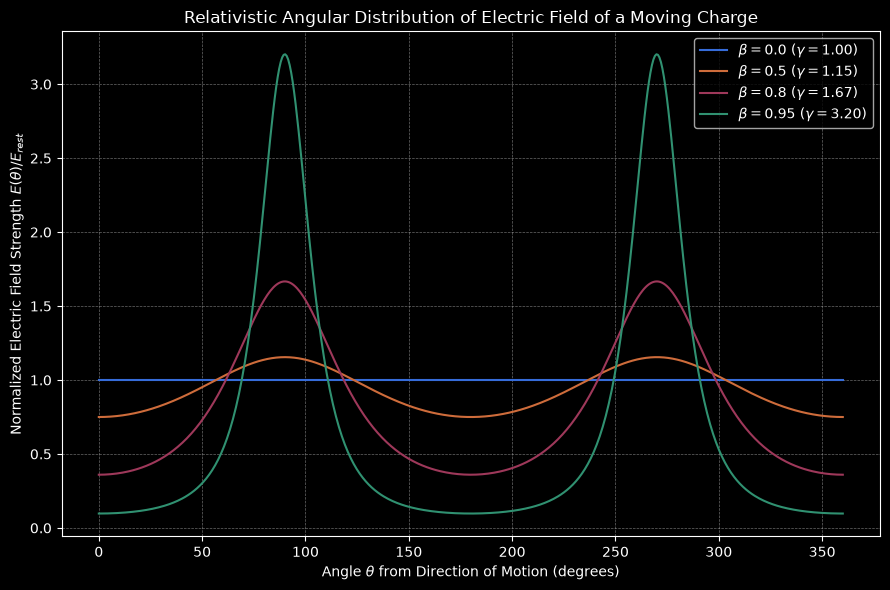

In [10]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 500)
betas = [0.0, 0.5, 0.8, 0.95]

plt.figure(figsize=(9, 6))

for beta_val in betas:
    gamma_val = 1.0 / np.sqrt(1 - beta_val**2)
    E_rel = (1 - beta_val**2) / (1 - beta_val**2 * np.sin(theta)**2)**(1.5)
    # Using raw f-string fr'...' prevents \b and \g from evaluating as escape characters
    plt.plot(np.degrees(theta), E_rel, label=fr'$\beta = {beta_val}$ ($\gamma = {gamma_val:.2f}$)')

plt.title(r"Relativistic Angular Distribution of Electric Field of a Moving Charge")
plt.xlabel(r"Angle $\theta$ from Direction of Motion (degrees)")
plt.ylabel(r"Normalized Electric Field Strength $E(\theta)/E_{rest}$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 6. University-Level References & Primary Sources

1. **Feynman Lectures on Physics, Volume II, Chapter 13 & 25**
   * *Link:* [https://www.feynmanlectures.caltech.edu/II_13.html](https://www.feynmanlectures.caltech.edu/II_13.html)
   * *Description:* Relativistic origins of magnetic fields and vector potential transformations.

2. **Einstein, A. (1905). "Zur Elektrodynamik bewegter Körper" (On the Electrodynamics of Moving Bodies)**
   * *Link:* [https://fourmilab.ch/etexts/einstein/specrel/www/](https://fourmilab.ch/etexts/einstein/specrel/www/)
   * *Description:* Original 1905 paper deriving Special Relativity directly from Maxwell's electrodynamics.

3. **MIT OpenCourseWare: Relativistic Electrodynamics (Physics 8.07 / 8.033)**
   * *Link:* [https://ocw.mit.edu/courses/8-033-relativity-fall-2006/](https://ocw.mit.edu/courses/8-033-relativity-fall-2006/)
   * *Description:* Advanced undergraduate lectures on 4-vector formulations of electrodynamics.

4. **Jackson, J. D. - Classical Electrodynamics (Chapter 11: Special Theory of Relativity)**
   * *Link:* [https://archive.org/details/ClassicalElectrodynamics3rdEd](https://archive.org/details/ClassicalElectrodynamics3rdEd)
   * *Description:* Standard graduate/undergraduate reference for covariant formulation of Maxwell's equations.
